# Compare CIFAR-100 Audit: DNLL vs Logistic (seed1234)

This notebook compares per-epoch audit metrics between DNLL and Logistic runs.
It expects both JSONL files in the same folder.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

dnll_path = "audit_cifar100_dnll_seed1234.jsonl"
logistic_path = "audit_cifar100_logistic_seed1234.jsonl"

dnll = pd.read_json(dnll_path, lines=True)
dnll['model'] = 'dnll'

logistic = pd.read_json(logistic_path, lines=True)
logistic['model'] = 'logistic'

df = pd.concat([dnll, logistic], ignore_index=True)
df.head()


,epoch,split,group,count,g_mean,g_median,g_p90,margin_mean,margin_median,margin_p90,...,p_neg_max_mean,p_neg_max_median,p_neg_max_p90,p_mix_mean,p_mix_median,p_mix_p90,metric,train_acc,test_acc,model
0,5,train,all,10000.0,0.148589,0.098102,0.318399,-0.279773,-0.270606,2.462157,...,0.148589,0.098102,0.318399,0.665919,0.588189,1.186321,NaN,NaN,NaN,dnll
1,5,train,hard5,500.0,0.683396,0.582631,1.019847,-2.614528,-2.302352,-0.483561,...,0.683396,0.582631,1.019847,1.157094,1.097622,1.624572,NaN,NaN,NaN,dnll
2,5,test,all,10000.0,0.153146,0.101363,0.325067,-0.439543,-0.409576,2.407208,...,0.153146,0.101363,0.325067,0.668129,0.591038,1.204121,NaN,NaN,NaN,dnll
3,5,test,hard5,500.0,0.719844,0.621275,1.131538,-2.813405,-2.394118,-0.688891,...,0.719844,0.621275,1.131538,1.181379,1.106378,1.715531,NaN,NaN,NaN,dnll
4,10,train,all,10000.0,0.135310,0.082114,0.311348,0.598027,0.594594,3.665045,...,0.135310,0.082114,0.311348,0.664437,0.562818,1.210362,NaN,NaN,NaN,dnll


In [2]:
df[['epoch', 'split', 'group', 'model']].drop_duplicates().sort_values(['epoch', 'split', 'group', 'model']).head(12)


,epoch,split,group,model
2,5,test,all,dnll
83,5,test,all,logistic
3,5,test,hard5,dnll
84,5,test,hard5,logistic
0,5,train,all,dnll
81,5,train,all,logistic
1,5,train,hard5,dnll
82,5,train,hard5,logistic
6,10,test,all,dnll
87,10,test,all,logistic


In [3]:
def plot_metric_compare(metric, split, group):
    subset = df[(df['split'] == split) & (df['group'] == group)]
    pivot = (
        subset
        .pivot_table(index='epoch', columns='model', values=metric)
        .sort_index()
    )
    ax = pivot.plot(marker='o', figsize=(8, 4))
    ax.set_title(f"{metric} by epoch ({split}, {group})")
    ax.set_xlabel('epoch')
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
    return ax


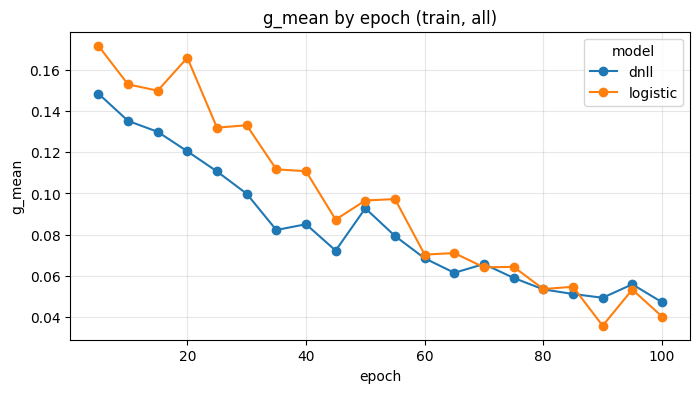

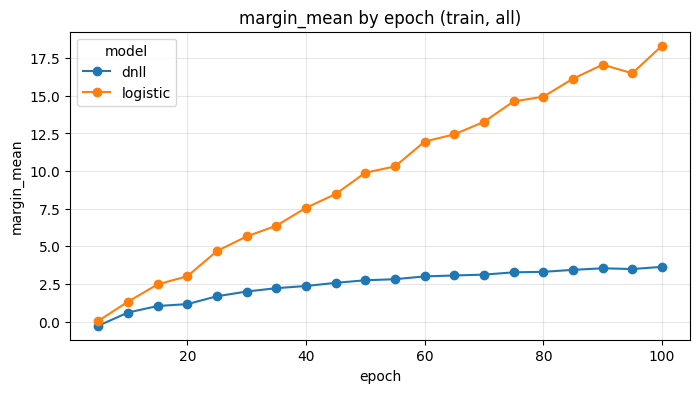

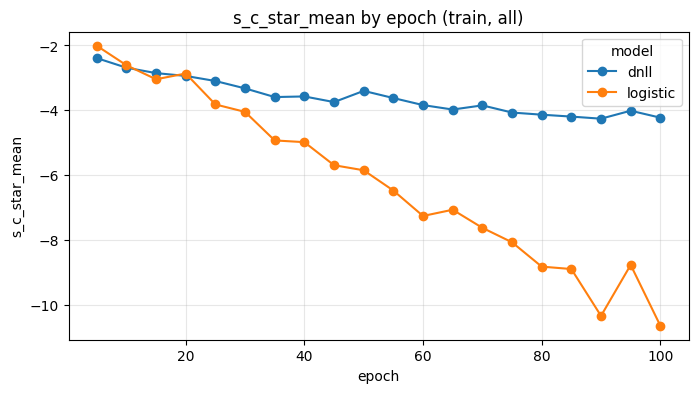

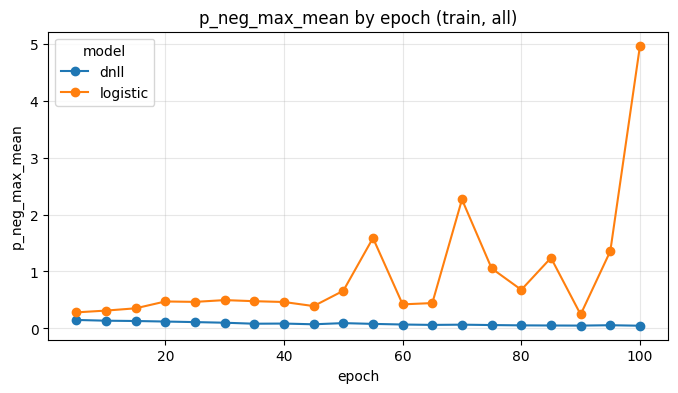

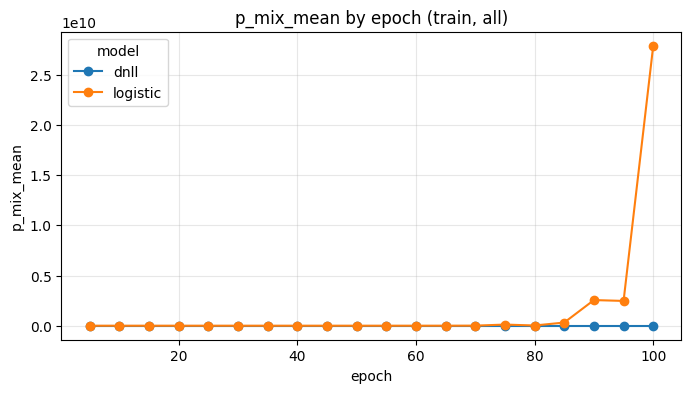

In [4]:
metrics = [
    'g_mean',
    'margin_mean',
    's_c_star_mean',
    'p_neg_max_mean',
    'p_mix_mean',
]

for metric in metrics:
    plot_metric_compare(metric, split='train', group='all')

plt.show()


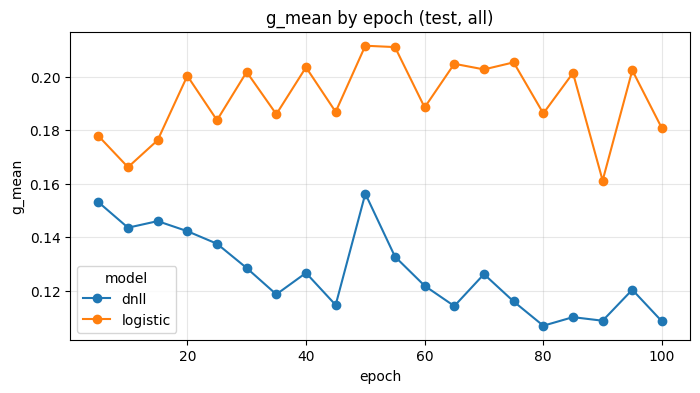

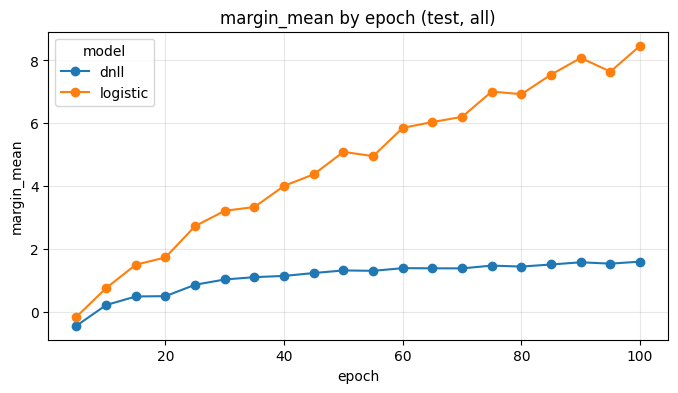

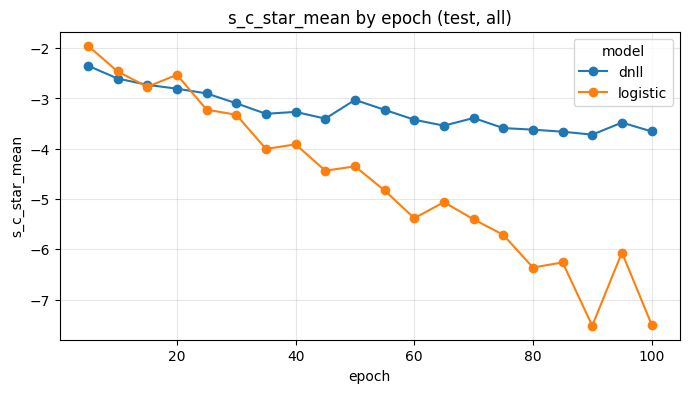

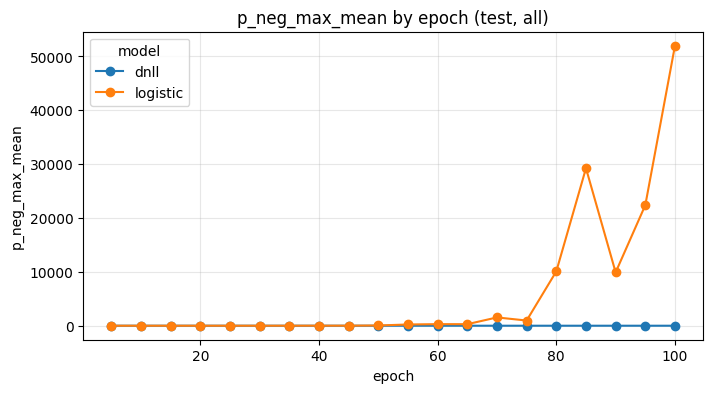

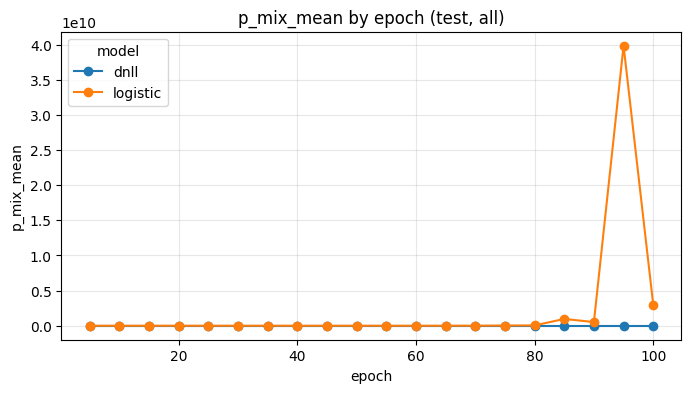

In [5]:
for metric in metrics:
    plot_metric_compare(metric, split='test', group='all')

plt.show()


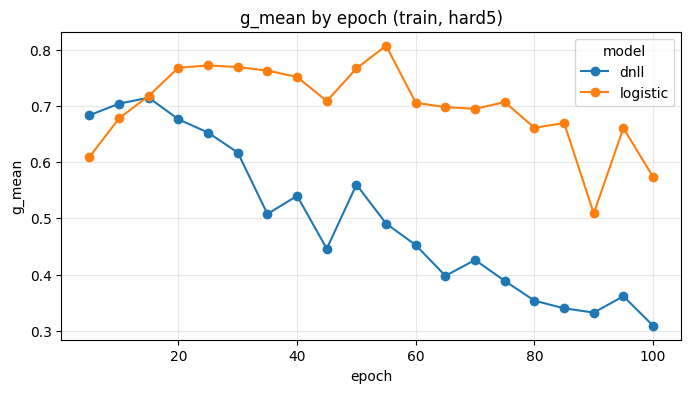

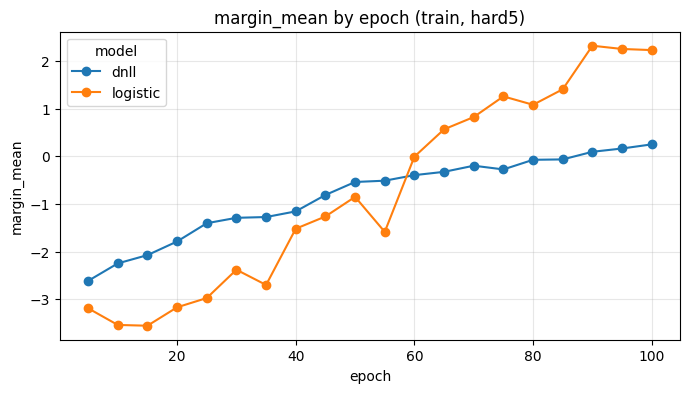

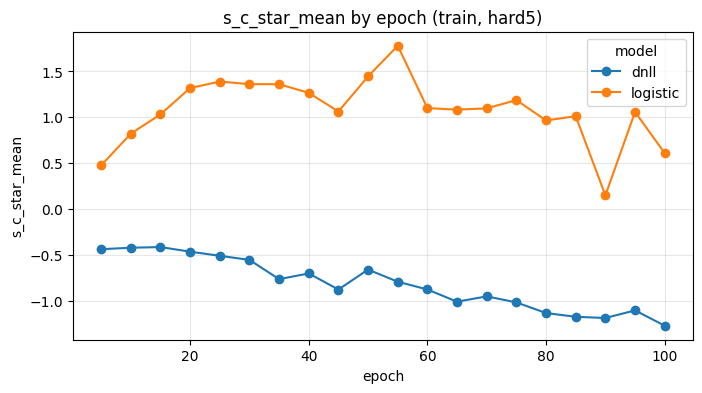

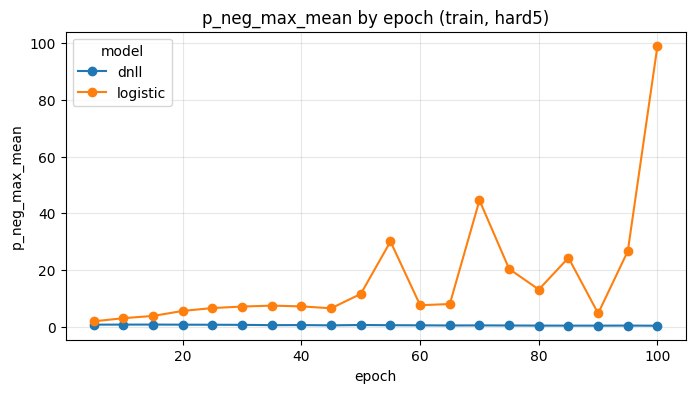

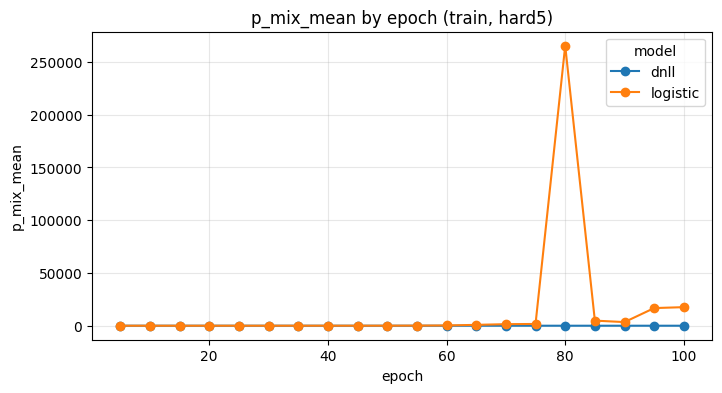

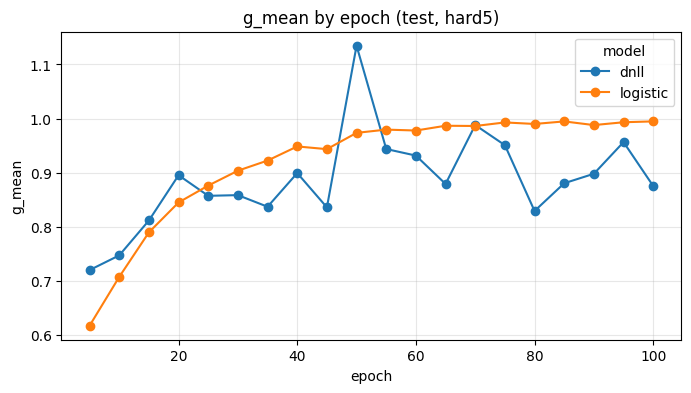

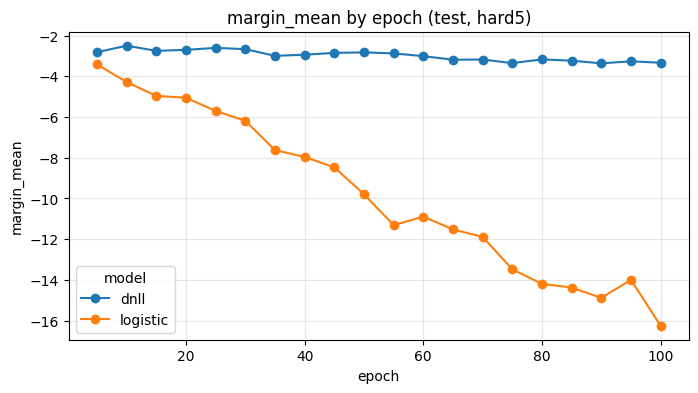

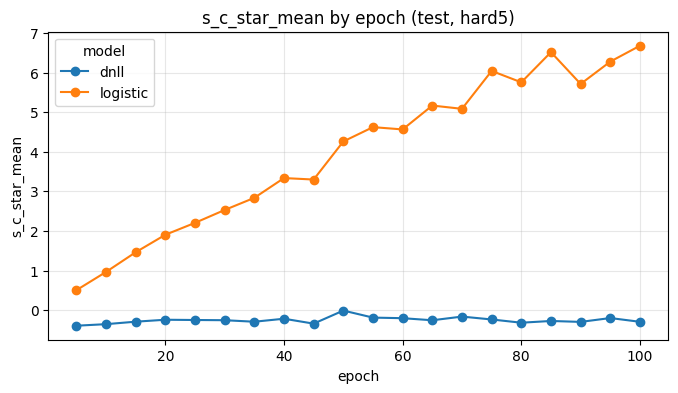

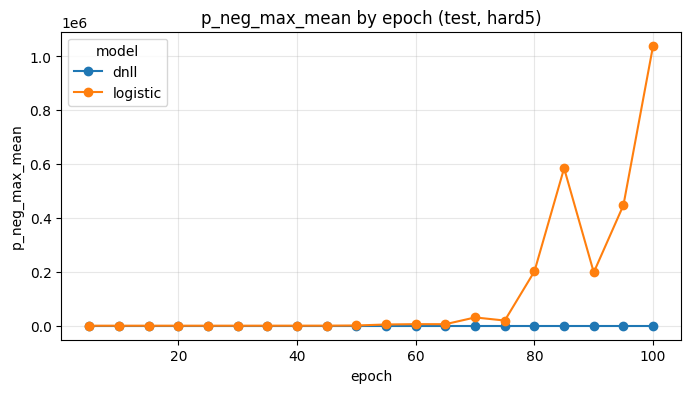

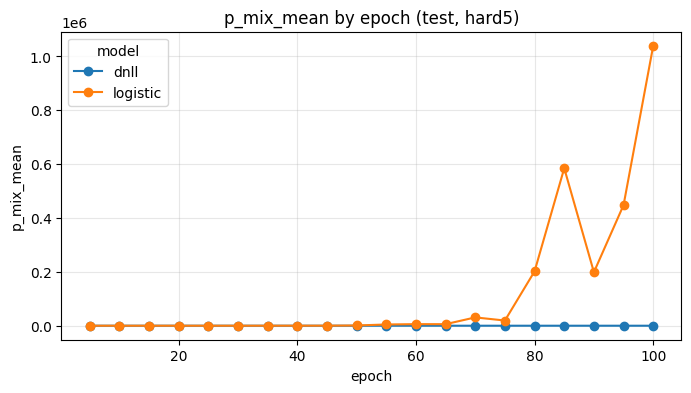

In [6]:
# Compare hard group (if present).
hard_groups = [g for g in df['group'].unique() if str(g).startswith('hard')]
if hard_groups:
    group = sorted(hard_groups)[0]
    for metric in metrics:
        plot_metric_compare(metric, split='train', group=group)
    plt.show()
    for metric in metrics:
        plot_metric_compare(metric, split='test', group=group)
    plt.show()
else:
    print('No hard groups found in data.')


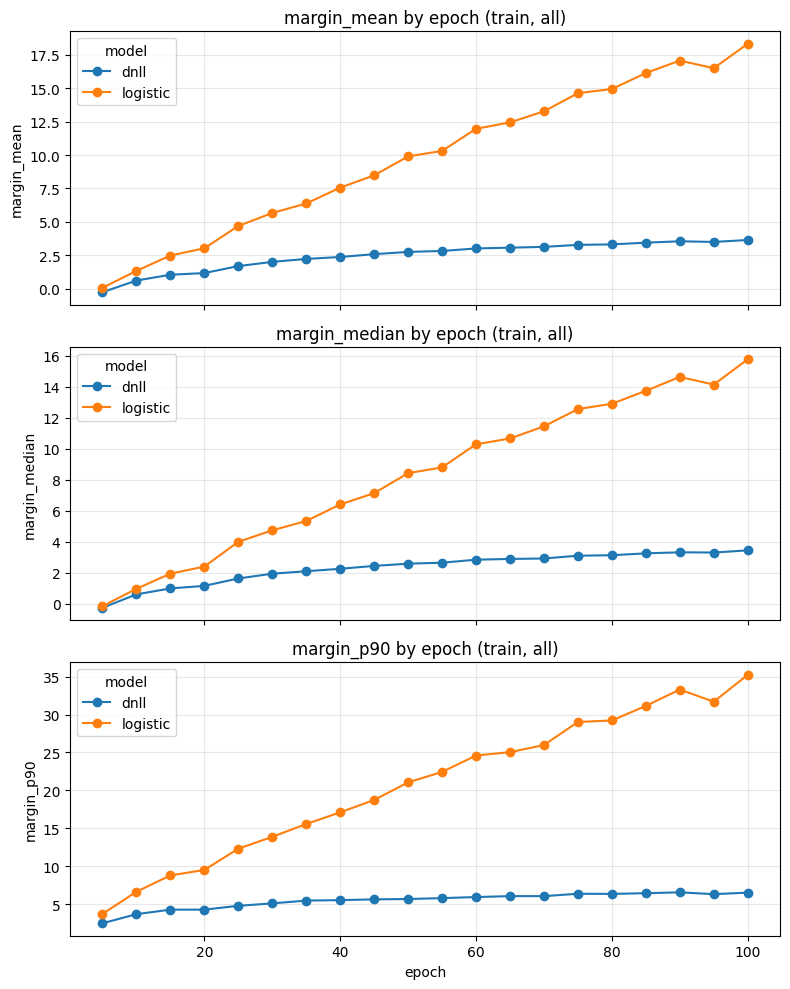

In [7]:
# Mean/median/p90 comparison for a chosen metric/split/group.
metric = 'margin'
split = 'train'
group = 'all'

cols = [f'{metric}_mean', f'{metric}_median', f'{metric}_p90']
subset = df[(df['split'] == split) & (df['group'] == group)]
pivot = subset.pivot_table(index='epoch', columns='model', values=cols)

fig, axes = plt.subplots(len(cols), 1, figsize=(8, 10), sharex=True)
for ax, col in zip(axes, cols):
    pivot[col].sort_index().plot(ax=ax, marker='o')
    ax.set_title(f'{col} by epoch ({split}, {group})')
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('epoch')
plt.tight_layout()
plt.show()
